# Smart Whiteboard / Document Scanner using Image Stitching

## Project Introduction

This Computer Vision project creates a **Smart Whiteboard / Document Scanner** that combines multiple overlapping images into one wider, cleaner panoramic/document image.

For example, if a whiteboard, notebook page, poster, or document is too large to capture in one photo, we can take **2 to 5 overlapping images** and stitch them together automatically.

The project uses:

- **OpenCV** for image processing
- **NumPy** for matrix operations
- **Matplotlib** for visualization
- **ORB** for keypoint detection
- **BFMatcher** for feature matching
- **RANSAC** for robust homography estimation
- **Perspective warping** for image alignment

## Problem Statement

Capturing a large whiteboard or document in a single image can be difficult because:

- The camera may not cover the full area.
- The image may be tilted or distorted.
- Important information may be spread across multiple photos.
- Manual editing is time-consuming.

The goal of this project is to automatically combine multiple overlapping images into one stitched output.

## Real-World Application

This project can be used in:

- Smart classroom whiteboard scanning
- Document scanning
- Poster scanning
- Panorama creation
- Lecture note digitization
- Office meeting board capture
- Mobile scanner applications

## Objectives

By the end of this notebook, you will be able to:

1. Upload multiple overlapping images in Google Colab.
2. Read and display images using OpenCV.
3. Convert images to grayscale.
4. Detect ORB keypoints and descriptors.
5. Match features using BFMatcher.
6. Estimate homography using RANSAC.
7. Warp images using perspective transformation.
8. Stitch images into one final image.
9. Handle errors when images do not overlap properly.
10. Compare manual stitching with OpenCV's built-in `cv2.Stitcher_create()`.

## Workflow Diagram

```text
Upload 2–5 Images
        |
        v
Read Images using OpenCV
        |
        v
Display Input Images
        |
        v
Convert Images to Grayscale
        |
        v
Detect ORB Keypoints and Descriptors
        |
        v
Match Features using BFMatcher
        |
        v
Filter Good Matches
        |
        v
Estimate Homography using RANSAC
        |
        v
Warp Image using Perspective Transform
        |
        v
Blend / Combine Images
        |
        v
Final Stitched Whiteboard / Document Image
```

## Algorithm Steps

1. Upload 2 to 5 overlapping images.
2. Load all images using OpenCV.
3. Convert images from BGR to RGB for display.
4. Convert images to grayscale for feature detection.
5. Use ORB to detect keypoints and compute descriptors.
6. Use BFMatcher with Hamming distance to match ORB descriptors.
7. Sort matches according to distance.
8. Select good matches using Lowe's ratio test.
9. Use matched points to estimate homography.
10. Apply RANSAC to remove outlier matches.
11. Warp one image into the coordinate system of the other image.
12. Combine both images into one larger canvas.
13. Repeat the process for multiple images.
14. Display intermediate and final results.

In [1]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

# OpenCV is used for computer vision operations.
import cv2

# NumPy is used for numerical and matrix operations.
import numpy as np

# Matplotlib is used to display images and results.
import matplotlib.pyplot as plt

# files allows image upload in Google Colab.
from google.colab import files

# os is used to handle file names.
import os

# This line makes plots appear inside the notebook.
%matplotlib inline

In [2]:
# ============================================================
# Step 2: Helper function to display one image
# ============================================================

def show_image(image, title="Image", figsize=(10, 6)):
    # Create a new figure.
    plt.figure(figsize=figsize)

    # If the image is grayscale, display it using gray colormap.
    if len(image.shape) == 2:
        plt.imshow(image, cmap="gray")
    else:
        # Convert BGR image to RGB before displaying.
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Add title.
    plt.title(title)

    # Hide axis values.
    plt.axis("off")

    # Display the image.
    plt.show()

In [3]:
# ============================================================
# Step 3: Helper function to display multiple images
# ============================================================

def show_images(images, titles=None, figsize=(18, 6)):
    # Count number of images.
    n = len(images)

    # Create titles if not provided.
    if titles is None:
        titles = [f"Image {i+1}" for i in range(n)]

    # Create figure.
    plt.figure(figsize=figsize)

    # Display every image.
    for i, image in enumerate(images):
        # Create subplot.
        plt.subplot(1, n, i + 1)

        # Display grayscale or color image.
        if len(image.shape) == 2:
            plt.imshow(image, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        # Add title.
        plt.title(titles[i])

        # Hide axis.
        plt.axis("off")

    # Show final plot.
    plt.show()

## Step 1: Upload 2–5 Overlapping Images

Upload images of the same whiteboard/document scene.

Important:

- Images must overlap.
- Consecutive images should share common visual features.
- Use clear images with enough texture or text.
- Avoid completely blank whiteboard areas because feature detection may fail.

In [5]:
# ============================================================
# Step 4: Upload images in Google Colab
# ============================================================

# Ask the user to upload image files.
uploaded = files.upload()

# Convert uploaded file names into a list.
image_paths = list(uploaded.keys())

# Check if the number of uploaded images is valid.
if len(image_paths) < 2 or len(image_paths) > 5:
    raise ValueError("Please upload between 2 and 5 overlapping images.")

# Print uploaded image names.
print("Uploaded images:")
for path in image_paths:
    print(path)

Saving Screenshot 2026-06-02 201121.png to Screenshot 2026-06-02 201121.png
Saving Screenshot 2026-06-02 201125.png to Screenshot 2026-06-02 201125.png
Saving Screenshot 2026-06-02 201129.png to Screenshot 2026-06-02 201129.png
Uploaded images:
Screenshot 2026-06-02 201121.png
Screenshot 2026-06-02 201125.png
Screenshot 2026-06-02 201129.png


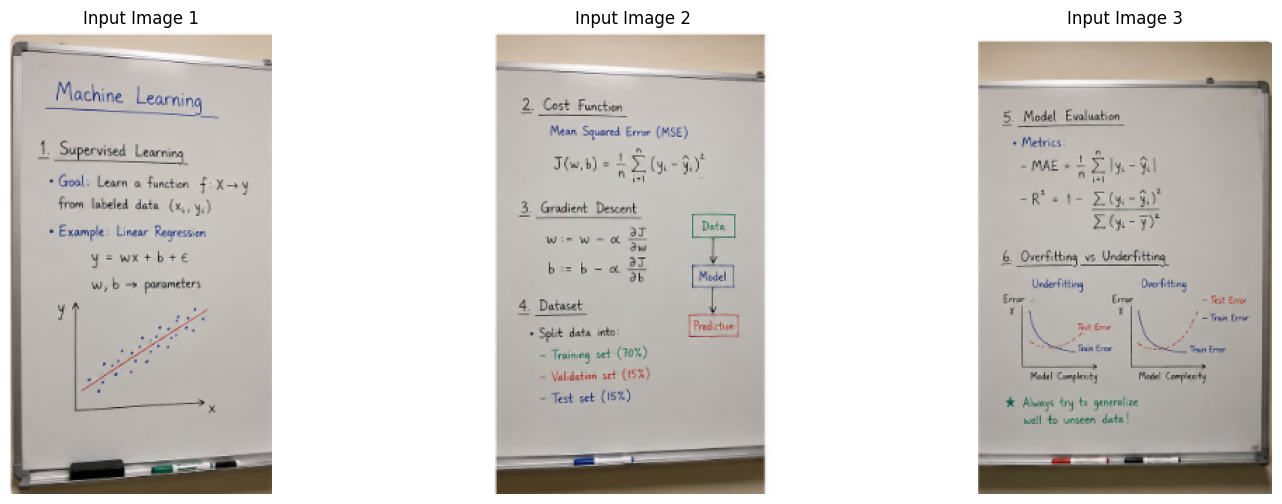

In [6]:
# ============================================================
# Step 5: Read uploaded images
# ============================================================

# Create an empty list to store images.
images = []

# Read every uploaded image.
for path in image_paths:
    # Read image using OpenCV.
    img = cv2.imread(path)

    # Check if image was loaded correctly.
    if img is None:
        raise ValueError(f"Could not read image: {path}")

    # Resize very large images to make processing faster.
    max_width = 1000

    # Get image height and width.
    h, w = img.shape[:2]

    # Resize only if image width is larger than max_width.
    if w > max_width:
        scale = max_width / w
        img = cv2.resize(img, (int(w * scale), int(h * scale)))

    # Add image to list.
    images.append(img)

# Display all input images.
show_images(images, titles=[f"Input Image {i+1}" for i in range(len(images))])

## Step 2: Convert Images to Grayscale

Feature detection works better on grayscale images because color is not necessary for detecting corners, edges, and texture patterns.

ORB detects important points from the intensity structure of the image.

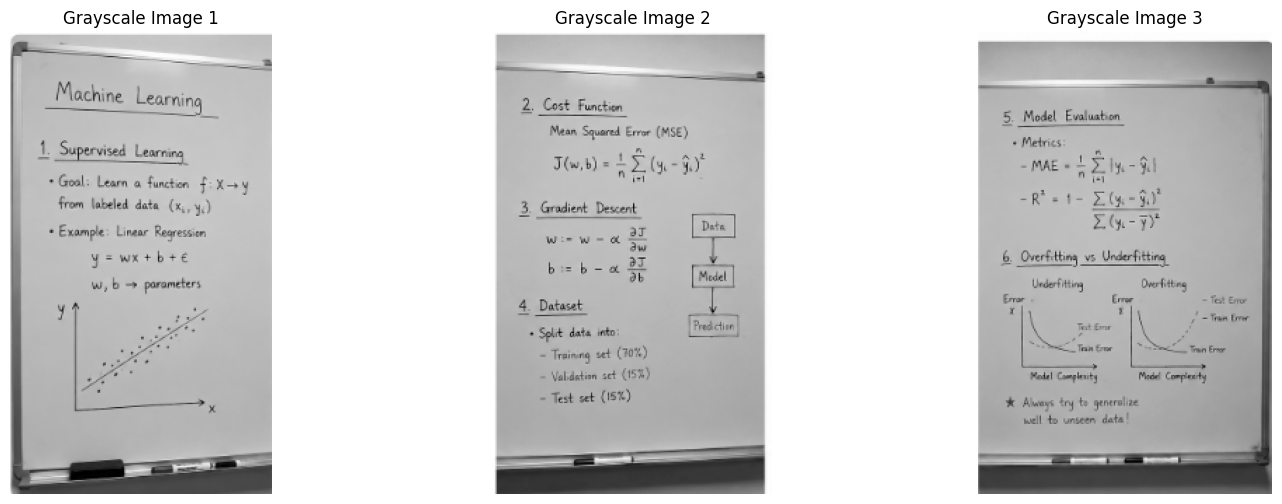

In [7]:
# ============================================================
# Step 6: Convert images to grayscale
# ============================================================

# Convert every BGR image into grayscale.
gray_images = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

# Display grayscale images.
show_images(gray_images, titles=[f"Grayscale Image {i+1}" for i in range(len(gray_images))])

## Step 3: Detect Keypoints using ORB

ORB means **Oriented FAST and Rotated BRIEF**.

It is used to detect and describe important points in an image.

A keypoint can be:

- A corner
- A sharp edge
- A textured region
- A unique pattern

ORB gives two outputs:

1. **Keypoints**: Locations of important points.
2. **Descriptors**: Binary feature vectors that describe each keypoint.

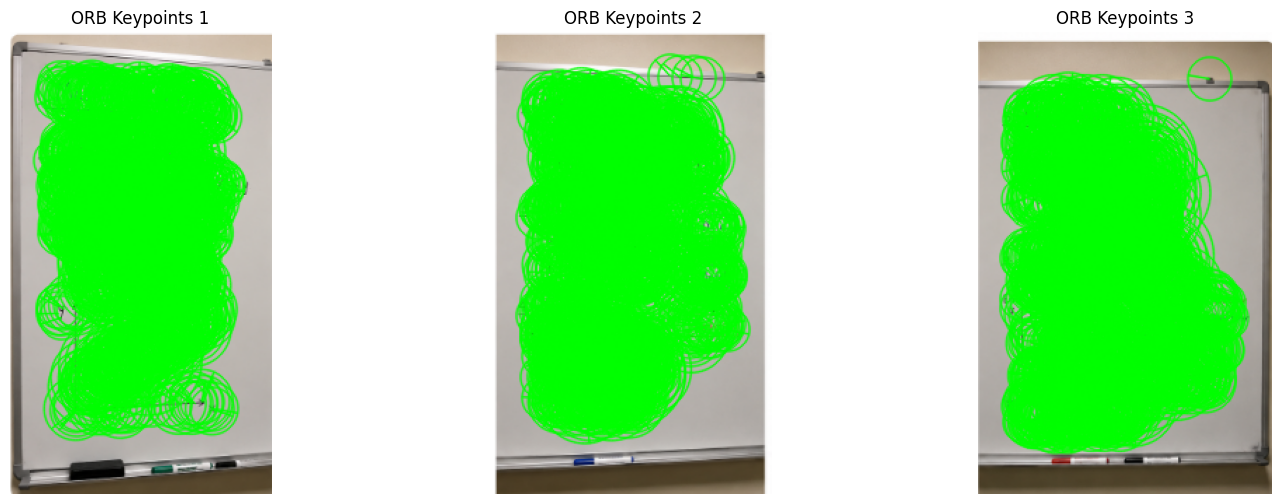

In [8]:
# ============================================================
# Step 7: Detect ORB keypoints and descriptors
# ============================================================

# Create ORB detector.
orb = cv2.ORB_create(nfeatures=3000)

# Lists to store keypoints and descriptors.
all_keypoints = []
all_descriptors = []

# Detect keypoints and descriptors for every grayscale image.
for gray in gray_images:
    # Detect keypoints and compute descriptors.
    keypoints, descriptors = orb.detectAndCompute(gray, None)

    # Store results.
    all_keypoints.append(keypoints)
    all_descriptors.append(descriptors)

# Display keypoints on each image.
keypoint_images = []

for i, img in enumerate(images):
    # Draw keypoints on image.
    kp_img = cv2.drawKeypoints(
        img,
        all_keypoints[i],
        None,
        color=(0, 255, 0),
        flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )

    # Store keypoint image.
    keypoint_images.append(kp_img)

# Show keypoints.
show_images(keypoint_images, titles=[f"ORB Keypoints {i+1}" for i in range(len(images))])

## Step 4: Feature Matching using BFMatcher

BFMatcher means **Brute Force Matcher**.

It compares descriptors from two images and finds matching features.

Since ORB creates binary descriptors, we use:

```python
cv2.NORM_HAMMING
```

This measures how different two binary descriptors are.

A smaller distance means a better match.

In [9]:
# ============================================================
# Step 8: Match features between two images
# ============================================================

def match_features(desc1, desc2):
    # Check if descriptors exist.
    if desc1 is None or desc2 is None:
        return []

    # Create BFMatcher for ORB descriptors.
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

    # Use KNN matching with k=2.
    matches = bf.knnMatch(desc1, desc2, k=2)

    # Apply Lowe's ratio test.
    good_matches = []

    for pair in matches:
        # Sometimes KNN may return less than 2 matches.
        if len(pair) < 2:
            continue

        # Get best and second-best match.
        m, n = pair

        # Keep match only if best match is much better than second-best.
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # Return good matches.
    return good_matches

Good matches between Image 1 and Image 2: 22


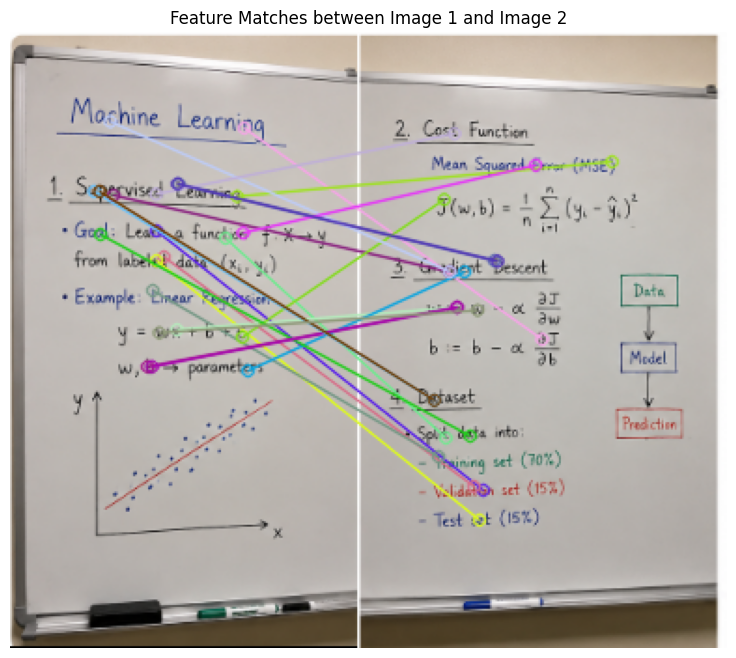

In [10]:
# ============================================================
# Step 9: Show feature matches between first two images
# ============================================================

# Match features between first and second image.
matches_12 = match_features(all_descriptors[0], all_descriptors[1])

# Print number of good matches.
print("Good matches between Image 1 and Image 2:", len(matches_12))

# Draw top matches.
match_display = cv2.drawMatches(
    images[0],
    all_keypoints[0],
    images[1],
    all_keypoints[1],
    matches_12[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Display matches.
show_image(match_display, title="Feature Matches between Image 1 and Image 2", figsize=(16, 8))

## Step 5: Estimate Homography using RANSAC

Homography is a 3×3 transformation matrix that maps points from one image plane to another.

It is useful when images are related by perspective transformation.

A homography matrix looks like:

```text
[ h11  h12  h13 ]
[ h21  h22  h23 ]
[ h31  h32  h33 ]
```

RANSAC is used because some feature matches are wrong. These wrong matches are called **outliers**.

RANSAC repeatedly selects random matches, estimates homography, and keeps the transformation with the largest number of correct matches.

In [11]:
# ============================================================
# Step 10: Compute homography using RANSAC
# ============================================================

def compute_homography(kp1, kp2, matches, min_matches=10):
    # Check if enough matches are available.
    if len(matches) < min_matches:
        raise ValueError(
            f"Not enough feature matches found. Found {len(matches)}, required at least {min_matches}. "
            "Images may not overlap."
        )

    # Extract matched points from image 1.
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Extract matched points from image 2.
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Compute homography using RANSAC.
    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

    # Check if homography was found.
    if H is None:
        raise ValueError("Homography could not be estimated. Images may not overlap properly.")

    # Return homography and mask.
    return H, mask

In [12]:
# ============================================================
# Step 11: Estimate homography between first two images
# ============================================================

try:
    # Compute homography from image 2 to image 1.
    H_12, mask_12 = compute_homography(
        all_keypoints[0],
        all_keypoints[1],
        matches_12
    )

    # Print homography matrix.
    print("Estimated Homography Matrix:")
    print(H_12)

    # Count inlier matches.
    inliers = int(mask_12.sum())
    print("RANSAC inliers:", inliers)

except ValueError as e:
    print("Error:", e)

Estimated Homography Matrix:
[[-6.93672578e-01 -3.19671657e-01  8.18417384e+01]
 [-7.41863905e-01 -4.98812004e-01  1.08084819e+02]
 [-8.11512016e-03 -4.05074522e-03  1.00000000e+00]]
RANSAC inliers: 7


## Step 6: Warp Image using Perspective Transform

After finding homography, we warp one image so that it aligns with the other image.

This is done using:

```python
cv2.warpPerspective()
```

The warped image is placed on a larger canvas so both images can fit.

In [13]:
# ============================================================
# Step 12: Stitch two images manually
# ============================================================

def stitch_pair(img1, img2, show_steps=False):
    # Convert both images to grayscale.
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Create ORB detector.
    orb = cv2.ORB_create(nfeatures=3000)

    # Detect keypoints and descriptors.
    kp1, desc1 = orb.detectAndCompute(gray1, None)
    kp2, desc2 = orb.detectAndCompute(gray2, None)

    # Match descriptors.
    matches = match_features(desc1, desc2)

    # Compute homography from img2 to img1.
    H, mask = compute_homography(kp1, kp2, matches)

    # Get image sizes.
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Define corners of img2.
    corners_img2 = np.float32([
        [0, 0],
        [0, h2],
        [w2, h2],
        [w2, 0]
    ]).reshape(-1, 1, 2)

    # Warp corners of img2 into img1 coordinate system.
    warped_corners_img2 = cv2.perspectiveTransform(corners_img2, H)

    # Define corners of img1.
    corners_img1 = np.float32([
        [0, 0],
        [0, h1],
        [w1, h1],
        [w1, 0]
    ]).reshape(-1, 1, 2)

    # Combine all corners.
    all_corners = np.concatenate((corners_img1, warped_corners_img2), axis=0)

    # Find minimum and maximum coordinates.
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Translation is needed if coordinates become negative.
    translation = [-x_min, -y_min]

    # Create translation matrix.
    T = np.array([
        [1, 0, translation[0]],
        [0, 1, translation[1]],
        [0, 0, 1]
    ])

    # Compute output canvas size.
    output_width = x_max - x_min
    output_height = y_max - y_min

    # Warp img2 using translated homography.
    warped_img2 = cv2.warpPerspective(img2, T @ H, (output_width, output_height))

    # Create canvas for result.
    result = warped_img2.copy()

    # Place img1 on the canvas.
    result[
        translation[1]:translation[1] + h1,
        translation[0]:translation[0] + w1
    ] = img1

    # Show intermediate steps if required.
    if show_steps:
        # Draw matches.
        match_img = cv2.drawMatches(
            img1,
            kp1,
            img2,
            kp2,
            matches[:50],
            None,
            matchesMask=mask.ravel().tolist()[:50],
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        # Show matches.
        show_image(match_img, title="Inlier Feature Matches", figsize=(16, 8))

        # Show warped image.
        show_image(warped_img2, title="Warped Image", figsize=(14, 8))

        # Show stitched result.
        show_image(result, title="Stitched Pair Result", figsize=(14, 8))

    # Return stitched result.
    return result

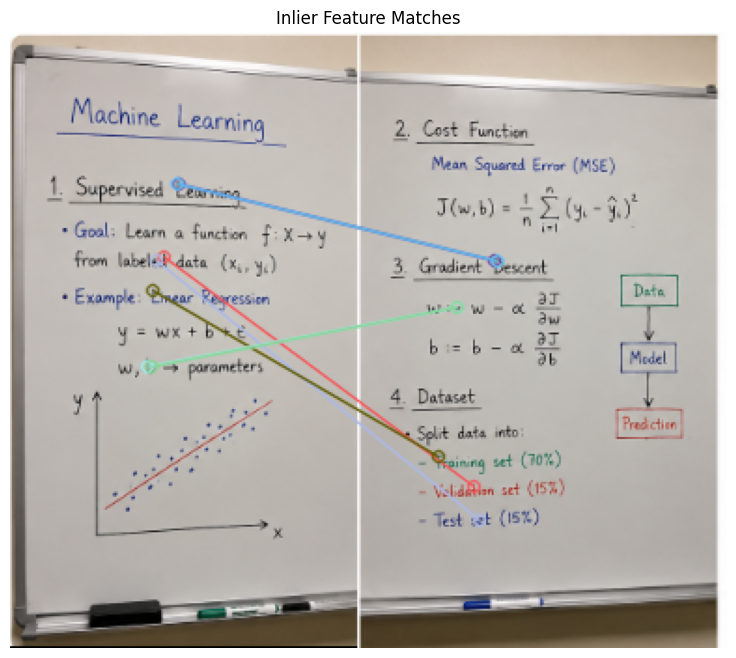

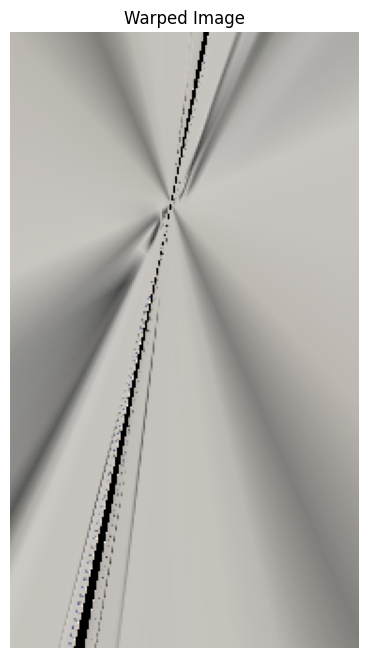

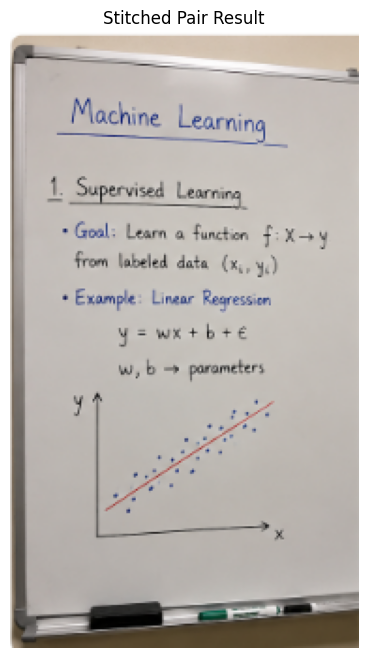

In [14]:
# ============================================================
# Step 13: Test stitching on first two images
# ============================================================

try:
    # Stitch first two images and show intermediate outputs.
    stitched_two = stitch_pair(images[0], images[1], show_steps=True)

except ValueError as e:
    print("Stitching failed:", e)

## Step 7: Stitch Multiple Images

For 2 to 5 uploaded images, we stitch images one by one.

Example:

```text
Image 1 + Image 2 = Result 1
Result 1 + Image 3 = Result 2
Result 2 + Image 4 = Result 3
Result 3 + Image 5 = Final Result
```

This simple method is easy for students to understand.

For best results, upload images in left-to-right or top-to-bottom order.

Stitching image 2 of 3...
Stitching image 3 of 3...


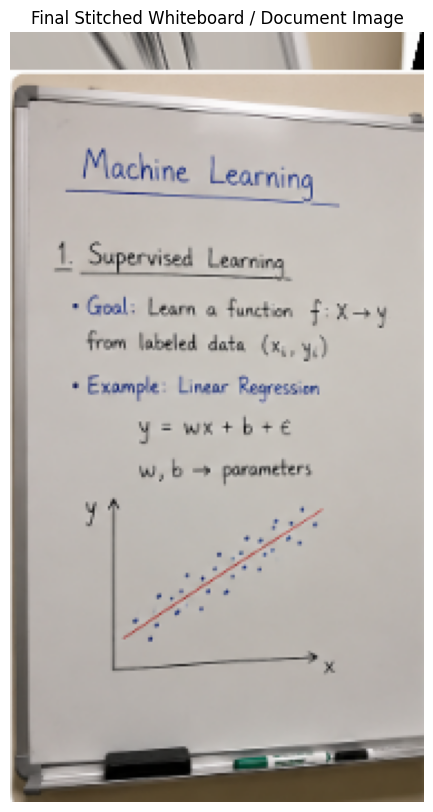

In [15]:
# ============================================================
# Step 14: Stitch all uploaded images
# ============================================================

def stitch_multiple_images(images):
    # Start with the first image.
    stitched = images[0]

    # Stitch remaining images one by one.
    for i in range(1, len(images)):
        print(f"Stitching image {i+1} of {len(images)}...")

        # Stitch current result with next image.
        stitched = stitch_pair(stitched, images[i], show_steps=False)

    # Return final stitched result.
    return stitched


try:
    # Stitch all uploaded images.
    final_stitched = stitch_multiple_images(images)

    # Display final stitched result.
    show_image(final_stitched, title="Final Stitched Whiteboard / Document Image", figsize=(16, 10))

except ValueError as e:
    print("Error during stitching:", e)
    print("Possible reasons:")
    print("1. Images do not overlap.")
    print("2. Images are too blurry.")
    print("3. There are not enough visible features.")
    print("4. Images are uploaded in the wrong order.")

## Step 8: Crop Black Borders

Warping may create black empty regions around the stitched image.

The next function removes most black borders by finding the bounding box of non-black pixels.

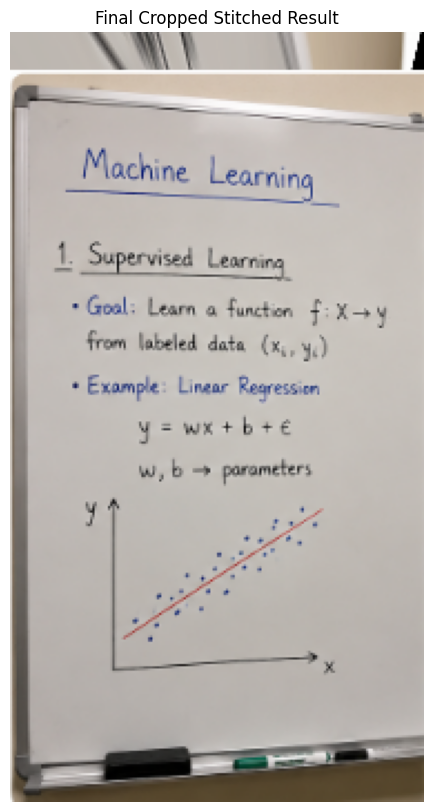

In [16]:
# ============================================================
# Step 15: Crop black borders from stitched image
# ============================================================

def crop_black_borders(image):
    # Convert image to grayscale.
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Create binary mask of non-black pixels.
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    # Find contours of non-black regions.
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # If no contour found, return original image.
    if not contours:
        return image

    # Get largest contour.
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding rectangle.
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Crop image.
    cropped = image[y:y+h, x:x+w]

    # Return cropped image.
    return cropped


try:
    # Crop final stitched result.
    cropped_result = crop_black_borders(final_stitched)

    # Display cropped result.
    show_image(cropped_result, title="Final Cropped Stitched Result", figsize=(16, 10))

except NameError:
    print("Final stitched image does not exist because stitching failed.")

## Optional Section: Using OpenCV Built-in Stitcher

OpenCV also provides an automatic stitcher:

```python
cv2.Stitcher_create()
```

This is easier to use, but it hides many internal steps.

For learning Computer Vision, the manual ORB + BFMatcher + RANSAC method is better because it shows how image stitching actually works.

In [17]:
# ============================================================
# Optional Step 16: Use OpenCV built-in Stitcher
# ============================================================

try:
    # Create OpenCV stitcher object.
    stitcher = cv2.Stitcher_create()

    # Perform automatic stitching.
    status, stitched_builtin = stitcher.stitch(images)

    # Check stitching status.
    if status == cv2.Stitcher_OK:
        print("OpenCV built-in stitcher succeeded.")
        show_image(stitched_builtin, title="OpenCV Built-in Stitcher Result", figsize=(16, 10))
    else:
        print("OpenCV built-in stitcher failed.")
        print("Status code:", status)
        print("Try using images with more overlap and clearer features.")

except Exception as e:
    print("Built-in stitcher error:", e)

OpenCV built-in stitcher failed.
Status code: 1
Try using images with more overlap and clearer features.


## Error Handling Notes

This notebook includes error handling for common problems:

### Problem 1: Not enough matches

This usually means the images do not overlap or have very few common features.

### Problem 2: Homography cannot be estimated

This can happen when feature matches are incorrect or images are too different.

### Problem 3: Wrong image order

Upload images in the correct sequence, such as left-to-right or top-to-bottom.

### Problem 4: Blank whiteboard areas

Blank areas do not contain enough keypoints, so ORB cannot match them well.

## Limitations

This simple stitching method has some limitations:

1. It works best when images have clear overlap.
2. It may fail on blank whiteboards or plain documents.
3. It does not perform advanced exposure correction.
4. It uses simple overlay instead of advanced blending.
5. It assumes images are uploaded in correct order.
6. It may produce visible seams.
7. Very large images may require resizing.
8. Strong perspective distortion may reduce accuracy.

## Conclusion

In this project, we created a beginner-friendly Smart Whiteboard / Document Scanner using Image Stitching.

We learned how to:

- Upload multiple images in Colab.
- Detect ORB keypoints.
- Match features using BFMatcher.
- Remove outliers using RANSAC.
- Estimate homography.
- Warp images using perspective transformation.
- Stitch multiple images into one final result.
- Use OpenCV's built-in stitcher as an optional comparison.

This project is useful for understanding real Computer Vision pipelines used in panorama generation, document scanning, and smart classroom applications.